In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler


# GMM 聚类

BIC 作为评价标准

### 读入数据，预处理

In [2]:
# ----------------------------------------------------
# 1. 读取融合后的特征空间数据
# ----------------------------------------------------
FEATURE_CSV = "Multi-Feature_result/fused_features_for_clustering-1Y.csv"
OUTPUT_DIR = "Multi-Feature_result/gmm_results-1Y"

os.makedirs(OUTPUT_DIR, exist_ok=True)

df_feat = pd.read_csv(FEATURE_CSV, index_col=0)  # index 是节点名
X = df_feat.values
node_names = df_feat.index.tolist()

print("Feature matrix shape:", X.shape)

# ----------------------------------------------------
# 2. （可选但强烈建议）整体再标准化一次
#    防止模块权重差异残留
# ----------------------------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

Feature matrix shape: (68, 45)


尝试PCA降维

达到 95% 累计解释方差所需的最小维度: 11


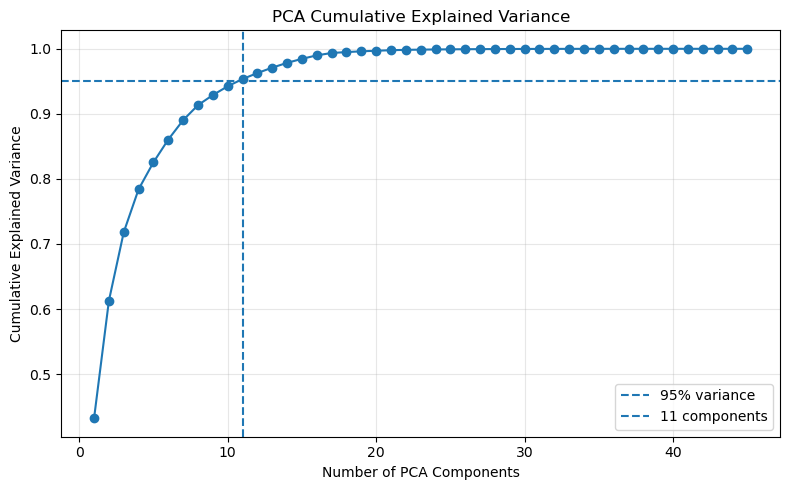

In [3]:
# ----------------------------------------------------
# 3. PCA：解释方差分析（用于决定降维维数）
# ----------------------------------------------------
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 先做一次不限制维度的 PCA，用于查看解释方差
pca_full = PCA()
pca_full.fit(X_std)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 找到达到 95% 解释方差所需的最小维度
dim_95 = np.searchsorted(cumulative_variance, 0.95) + 1

print(f"达到 95% 累计解释方差所需的最小维度: {dim_95}")

# ----------------------------------------------------
# 4. 绘制累计解释方差曲线
# ----------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)
plt.axhline(0.95, linestyle='--', label='95% variance')
plt.axvline(dim_95, linestyle='--', label=f'{dim_95} components')

plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ----------------------------------------------------
# 5. PCA 降维
# ----------------------------------------------------
TARGET_DIM = 11   # 你假设的目标维度

pca = PCA(n_components=TARGET_DIM)
X_pca = pca.fit_transform(X_std)

print("PCA-reduced feature shape:", X_pca.shape)

PCA-reduced feature shape: (68, 11)


### 试探聚类


===== GMM with K = 2 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

BIC: 2432.35
Probability file saved to: Multi-Feature_result/gmm_results-1Y\gmm_probabilities_K2.csv

===== GMM with K = 3 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

BIC: 2017.03
Probability file saved to: Multi-Feature_result/gmm_results-1Y\gmm_probabilities_K3.csv

===== GMM with K = 4 =====
BIC: 1825.34


...

BIC: 2167.20
Probability file saved to: Multi-Feature_result/gmm_results-1Y\gmm_probabilities_K18.csv

===== GMM with K = 19 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

BIC: 2234.23
Probability file saved to: Multi-Feature_result/gmm_results-1Y\gmm_probabilities_K19.csv

===== GMM with K = 20 =====


d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
d:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than avai

BIC: 2950.33
Probability file saved to: Multi-Feature_result/gmm_results-1Y\gmm_probabilities_K20.csv


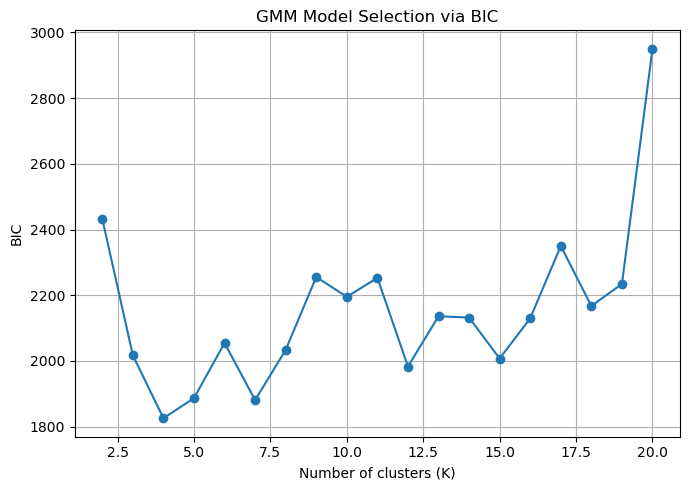

In [5]:
# ----------------------------------------------------
# GMM 聚类：K = 2 ~ 10
# ----------------------------------------------------
bic_scores = []
k_range = range(2, 21)

for k in k_range:
    print(f"\n===== GMM with K = {k} =====")

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        n_init=10,
        random_state=42
    )

    gmm.fit(X_pca)

    # -------- BIC --------
    bic = gmm.bic(X_pca)
    bic_scores.append(bic)
    print(f"BIC: {bic:.2f}")

    # -------- 软分配概率 --------
    prob = gmm.predict_proba(X_pca)  # shape: (n_samples, k)

    prob_df = pd.DataFrame(
        prob,
        index=node_names,
        columns=[f"Cluster_{i}" for i in range(k)]
    )

    out_csv = os.path.join(
        OUTPUT_DIR,
        f"gmm_probabilities_K{k}.csv"
    )
    prob_df.to_csv(out_csv)

    print(f"Probability file saved to: {out_csv}")

# ----------------------------------------------------
# 4. 绘制 BIC 曲线
# ----------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(list(k_range), bic_scores, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("BIC")
plt.title("GMM Model Selection via BIC")
plt.grid(True)
plt.tight_layout()
plt.show()

### 聚类后检验有无物理意义

可尝试的聚类数目：4, 7

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
import math

def plot_cluster_pie_by_space_usage(K):
    """
    根据 GMM soft assignment 概率结果绘制 cluster 饼图

    Parameters
    ----------
    K : int
        聚类数量，对应文件 gmm_probabilities_K{K}.csv
    """

    # =========================
    # 0. 全局绘图风格（完全复刻）
    # =========================
    mpl.rcParams["font.family"] = "Times New Roman"
    mpl.rcParams["font.size"] = 12

    title_fontsize = 29
    legend_fontsize = 25
    legend_title_fontsize = 28

    # =========================
    # 1. 读取数据（概率矩阵）
    # =========================
    csv_path = os.path.join(
        "Multi-Feature_result",
        "gmm_results",
        f"gmm_probabilities_K{K}.csv"
    )

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"File not found: {csv_path}")

    # 第一列是节点名
    df_prob = pd.read_csv(csv_path, index_col=0)

    # =========================
    # 2. 从概率中推断 hard label
    # =========================
    # 找概率最大的 cluster
    cluster_cols = [col for col in df_prob.columns if col.startswith("Cluster_")]
    df_prob["label"] = (
        df_prob[cluster_cols]
        .idxmax(axis=1)
        .str.replace("Cluster_", "")
        .astype(int)
    )

    # 节点名作为一列，方便后续处理
    df_prob["location"] = df_prob.index

    # 拆分 location，取第二个单词（与你原始代码完全一致）
    df_prob["second_word"] = df_prob["location"].str.split("_").str[1]

    # =========================
    # 3. 颜色映射（完全一致）
    # =========================
    word_colors = {
        "education": "#D62728",  # red
        "office": "#2CA02C",     # green
        "lodging": "#1F77B4",    # blue
        "health": "#9467BD",     # purple
        "science": "#7F7F7F",    # gray
        "public": "#F1C40F",     # yellow
        "assembly": "#FF7F0E",   # orange
    }

    # =========================
    # 4. 统计每个 cluster 的 second_word
    # =========================
    labels = sorted(df_prob["label"].unique())
    stats = {}

    print("\n========== Label Statistics ==========\n")

    for lb in labels:
        words = df_prob.loc[df_prob["label"] == lb, "second_word"]
        counter = Counter(words)
        stats[lb] = counter

        print(f"Cluster {lb}")
        print(f"  Total samples: {len(words)}")
        print("  Second word counts:")
        for k, v in counter.items():
            print(f"    {k}: {v}")
        print("-" * 40)

    # 所有出现过的 second_word（统一顺序，统一图例）
    all_words = sorted(df_prob["second_word"].unique())
    colors = [word_colors[w] for w in all_words]

    # =========================
    # 5. 自动布局（根据 K）
    # =========================
    n_cols = math.ceil(math.sqrt(K))
    n_rows = math.ceil(K / n_cols)

    fig = plt.figure(figsize=(6 * n_cols, 5 * n_rows))
    axes = []

    for i in range(K):
        ax = plt.subplot(n_rows, n_cols, i + 1)
        axes.append(ax)

    # =========================
    # 6. 绘制饼图
    # =========================
    legend_handles = None

    for lb, ax in zip(labels, axes):
        counter = stats[lb]
        sizes = [counter.get(w, 0) for w in all_words]

        wedges, texts = ax.pie(
            sizes,
            colors=colors,
            startangle=90
        )

        ax.set_title(f"Cluster {lb}", fontsize=title_fontsize)
        ax.axis("equal")

        if legend_handles is None:
            legend_handles = wedges

    # =========================
    # 7. 统一图例
    # =========================
    fig.legend(
        legend_handles,
        all_words,
        loc="center right",
        fontsize=legend_fontsize,
        title="Primary Space Usage",
        title_fontsize=legend_title_fontsize
    )

    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()


    # =========================
    # 8. 读取电力负荷时间序列
    # =========================
    ts_path = os.path.join(
        "..", "..",
        "electricityLondon",
        "electricityLondon_24hfilled.csv"
    )

    if not os.path.exists(ts_path):
        raise FileNotFoundError(f"File not found: {ts_path}")

    df_ts = pd.read_csv(ts_path)

    # 去掉 timestamp 列
    if "timestamp" in df_ts.columns:
        df_ts = df_ts.drop(columns=["timestamp"])


    # 每列是一个节点
    node_names = df_ts.columns.tolist()
    series_length = len(df_ts)

    # 转成 numpy，方便画图
    X = df_ts.values.T   # shape: (N_nodes, T)

    # =========================
    # 9. 绘制每个 cluster 的负荷曲线
    # =========================
    output_dir = os.path.join(
        "Multi-Feature_result",
        "cluster_timeseries_plots",
        f"K{K}"
    )

    os.makedirs(output_dir, exist_ok=True)

    # 将 label 转换为数组
    labels_array = df_prob.loc[node_names, "label"].values

    print("\n========== Plot Cluster Time Series ==========\n")

    for cid in range(K):

        member_idx = [i for i, lb in enumerate(labels_array) if lb == cid]

        if len(member_idx) == 0:
            continue

        fig, ax = plt.subplots(figsize=(12, 4))

        # 画所有成员
        for i in member_idx:
            ax.plot(
                range(series_length),
                X[i],
                linewidth=0.6,
                alpha=0.7,
                zorder=1,
                color="0.6",
                solid_capstyle="round"
            )

        # cluster center（均值）
        center_series = X[member_idx].mean(axis=0)

        ax.plot(
            range(series_length),
            center_series,
            linewidth=1.5,
            color="red",
            zorder=2,
            label="Cluster center (mean)"
        )

        # 坐标轴
        ax.set_xlabel("Time step", fontsize=12)
        ax.set_ylabel("Electricity load", fontsize=12)
        ax.set_title(f"Cluster {cid} — {len(member_idx)} series", fontsize=14)

        # xtick 每 500
        tick_step = 500
        ticks = list(range(0, series_length, tick_step))

        if (series_length - 1) not in ticks:
            ticks.append(series_length - 1)

        ax.set_xticks(ticks)
        ax.set_xticklabels([str(t) for t in ticks], fontsize=10)

        ax.grid(False)

        plt.tight_layout()

        out_png = os.path.join(
            output_dir,
            f"cluster_{cid}_members_with_center.png"
        )

        fig.savefig(out_png, dpi=300)
        plt.close(fig)

        print(f"Cluster {cid} time series saved: {out_png}")

    print("\nAll cluster time series plots saved to:", output_dir)


========== Label Statistics ==========

Cluster 0
  Total samples: 50
  Second word counts:
    public: 2
    lodging: 11
    education: 13
    office: 22
    assembly: 1
    health: 1
----------------------------------------
Cluster 1
  Total samples: 6
  Second word counts:
    education: 2
    office: 3
    health: 1
----------------------------------------
Cluster 2
  Total samples: 3
  Second word counts:
    education: 1
    health: 1
    science: 1
----------------------------------------
Cluster 3
  Total samples: 9
  Second word counts:
    education: 6
    office: 1
    health: 2
----------------------------------------


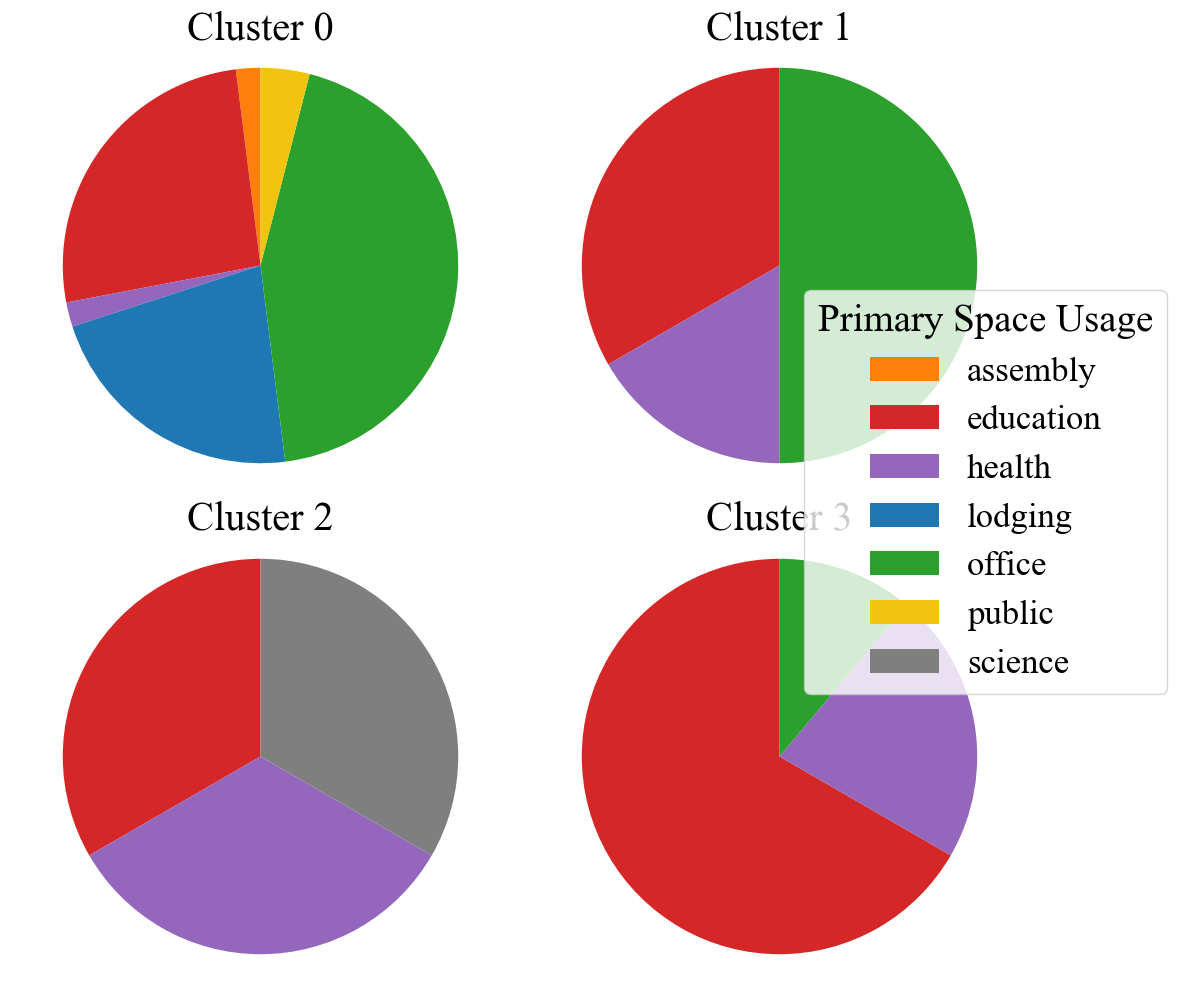


========== Plot Cluster Time Series ==========

Cluster 0 time series saved: Multi-Feature_result\cluster_timeseries_plots\K4\cluster_0_members_with_center.png
Cluster 1 time series saved: Multi-Feature_result\cluster_timeseries_plots\K4\cluster_1_members_with_center.png
Cluster 2 time series saved: Multi-Feature_result\cluster_timeseries_plots\K4\cluster_2_members_with_center.png
Cluster 3 time series saved: Multi-Feature_result\cluster_timeseries_plots\K4\cluster_3_members_with_center.png

All cluster time series plots saved to: Multi-Feature_result\cluster_timeseries_plots\K4


In [13]:
plot_cluster_pie_by_space_usage(4)


========== Label Statistics ==========

Cluster 0
  Total samples: 11
  Second word counts:
    education: 5
    office: 5
    lodging: 1
----------------------------------------
Cluster 1
  Total samples: 3
  Second word counts:
    education: 1
    health: 1
    science: 1
----------------------------------------
Cluster 2
  Total samples: 7
  Second word counts:
    education: 5
    office: 1
    health: 1
----------------------------------------
Cluster 3
  Total samples: 16
  Second word counts:
    office: 12
    education: 2
    lodging: 1
    health: 1
----------------------------------------
Cluster 4
  Total samples: 2
  Second word counts:
    education: 1
    health: 1
----------------------------------------
Cluster 5
  Total samples: 5
  Second word counts:
    education: 1
    office: 3
    health: 1
----------------------------------------
Cluster 6
  Total samples: 24
  Second word counts:
    public: 2
    lodging: 9
    education: 7
    office: 5
    assembly: 1
---

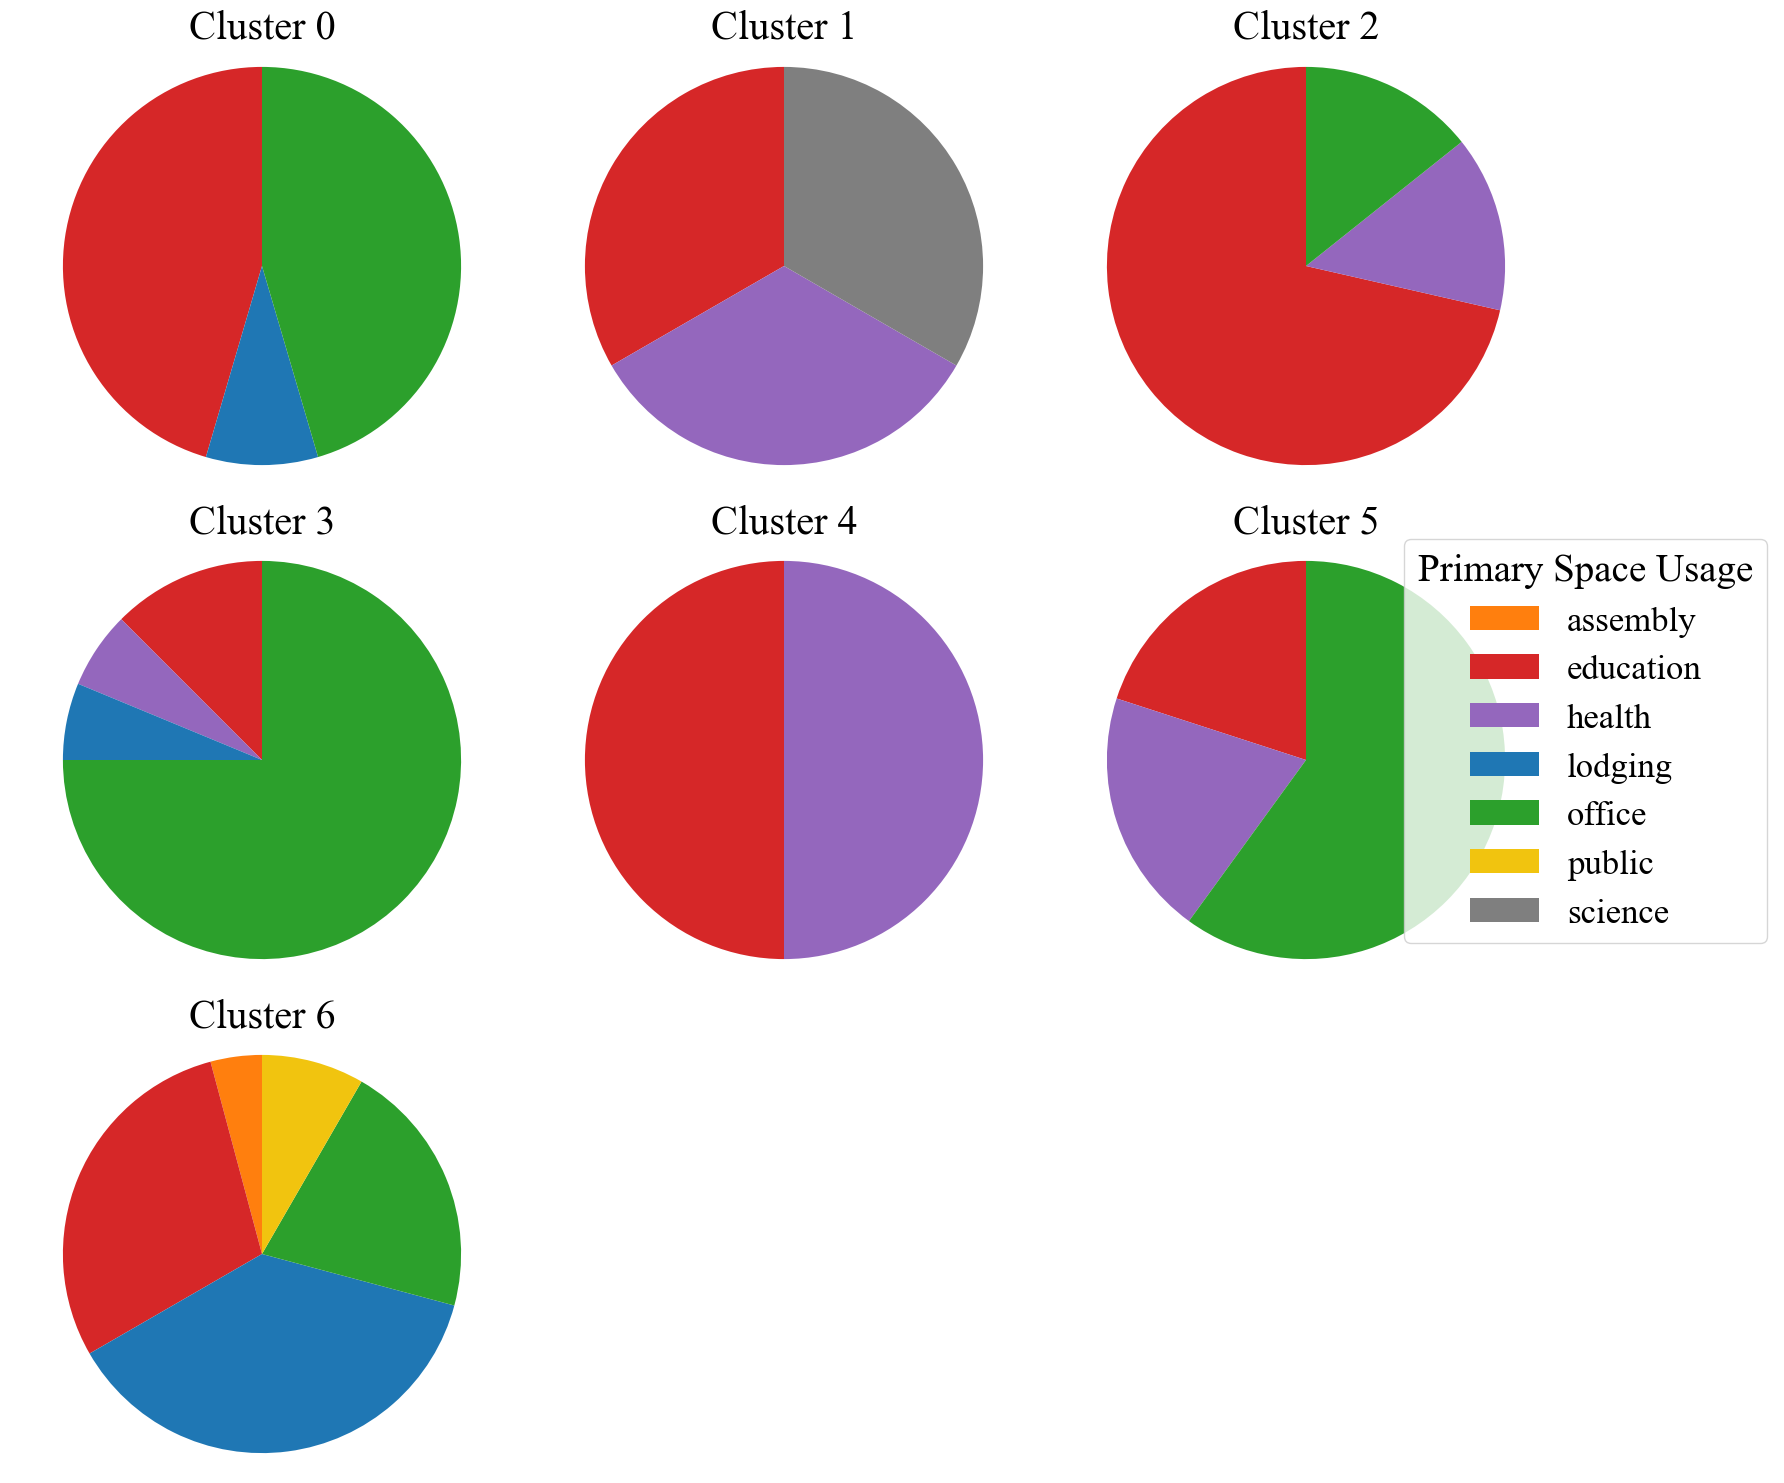

In [9]:
plot_cluster_pie_by_space_usage(7)